# Galería de validación: puremacro frente a referencias confiables

Cada estimador principal de `puremacro` se contrasta con una referencia
**independiente**: `statsmodels` / `linearmodels` / `arch` / `scipy` cuando
existe, una solución en forma cerrada, un número publicado, o una identidad
interna entre métodos. Las comprobaciones viven en `puremacro.validation` como
un registro declarativo de casos, de modo que **cualquiera puede reverificar la
biblioteca** — incluso en el navegador:

```python
from puremacro.validation import scorecard
scorecard()            # puremacro frente a la referencia, una fila por caso
```

Este cuaderno renderiza ese tablero y algunas superposiciones representativas
lado a lado. Importa solo la pila compatible con pyodide (numpy/scipy/pandas/
matplotlib + `puremacro`), así que corre sin cambios en el playground de
JupyterLite: las cifras de comparación con paquetes se leen de valores *golden*
congelados, mientras que las referencias de forma cerrada / scipy se recalculan
en vivo.

## ¿Por qué validar?

Una biblioteca de macroeconomía en Python puro solo vale la pena si se puede
confiar en sus números. Reimplementar desde cero en numpy un VAR, un filtro de
Kalman o un estimador GARCH es justo donde se esconden los errores silenciosos
—un desfase de un rezago, una matriz transpuesta, una normalización equivocada—
y ninguno se anuncia por sí solo.

**Intuición.** Aquí la confianza se *gana por estimador, frente a algo
independiente*. Cada caso de `puremacro.validation` empareja un estimador de
puremacro con una referencia que el propio código de puremacro no produjo,
declara **cómo** se obtiene esa referencia (su *mecanismo*) y **con qué
exactitud** deben coincidir ambos (su *nivel de tolerancia*), y luego informa si
pasa o falla. La independencia de la referencia es todo el argumento: comparar
la biblioteca consigo misma no probaría nada.

- **Mecanismo** — `PACKAGE` (statsmodels / linearmodels / arch, capturado una
  vez como *golden* congelado para que la biblioteca nunca importe el paquete
  pesado en tiempo de ejecución), `SCIPY` (scipy/numpy, recalculado en vivo),
  `ANALYTICAL` (una solución en forma cerrada), `PUBLISHED` (un número de un
  artículo, con cita), `INTERNAL` (una identidad entre métodos, p. ej. EGM =
  VFI, o una comprobación de simular-y-recuperar).
- **Nivel de tolerancia** — `EXACT` (rtol $10^{-10}$), `TIGHT` ($10^{-6}$),
  `NUMERIC` ($10^{-2}$), `COARSE` (10%), `QUALITATIVE` (un signo, un orden, o un
  umbral de cota inferior). El nivel se elige para ajustarse a lo que la
  referencia puede certificar con honestidad —precisión de máquina para una
  identidad algebraica, una banda más holgada para una estimación de
  simular-y-recuperar.

Mantener las referencias `PACKAGE` como golden congelados (reguardados contra
los paquetes en vivo en CI) es lo que permite que el *mismo* `scorecard()` corra
en el navegador sin tener statsmodels/linearmodels/arch instalados.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = __import__("pathlib").Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.validation import run_all, scorecard

## 1. El tablero (scorecard)
Una fila por caso de validación: a qué subsistema pertenece, el *mecanismo* de
referencia (`package` = frente a statsmodels/linearmodels/arch mediante un
golden congelado; `scipy`, `analytical`, `published`, `internal`), el nivel de
tolerancia, si pasa, y el margen de seguridad (`max_margin <= 0` significa
dentro de tolerancia). El `assert` siguiente es la biblioteca verificándose a
sí misma.

In [2]:
df = scorecard()
n, n_pass = len(df), int(df["passed"].sum())
print(f"{n_pass}/{n} validation cases pass across {df['subsystem'].nunique()} subsystems")
assert df["passed"].all(), "a validation case failed"
print("by mechanism:", df["mechanism"].value_counts().to_dict())
print("by tolerance:", df["tol"].value_counts().to_dict())

# Per-subsystem summary: how many cases, which mechanisms, worst (largest) margin.
agg = (
    df.groupby("subsystem")
    .agg(
        n_cases=("id", "size"),
        mechanisms=("mechanism", lambda s: "+".join(sorted(s.unique()))),
        all_pass=("passed", "all"),
        worst_margin=("max_margin", "max"),
    )
    .sort_values("n_cases", ascending=False)
)
agg

61/61 validation cases pass across 11 subsystems
by mechanism: {'internal': 29, 'analytical': 15, 'package': 11, 'scipy': 5, 'published': 1}
by tolerance: {'tight': 26, 'exact': 15, 'numeric': 10, 'qualitative': 7, 'coarse': 3}


,n_cases,mechanisms,all_pass,worst_margin
subsystem,,,,
narrative,7,analytical+internal,True,-1.000000e-12
dsge,6,analytical+internal,True,-9.999293e-13
dynpanel,6,analytical+internal,True,-1.000000e-12
garch,6,internal+package,True,-1.000000e-12
inference,6,analytical+internal+package+published,True,-5.400000e-10
spectral,6,internal+scipy,True,-1.010000e-10
state_space,6,internal+package,True,0.000000e+00
forecast,5,analytical+internal,True,-1.000000e-12
lp,5,internal+package,True,-9.999993e-10


### Figura principal — cobertura de un vistazo
Todos los subsistemas, todos los casos en verde. La mezcla de mecanismos de
referencia muestra que la galería abarca contrastes con paquetes en vivo,
scipy, forma cerrada, valores publicados e identidades de consistencia interna.

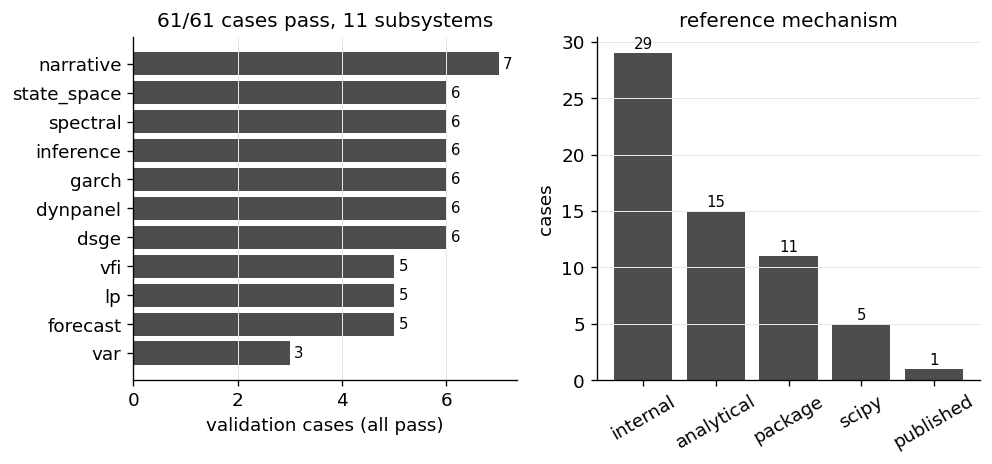

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(8.4, 4.0))

a = agg.sort_values("n_cases")
axL.barh(a.index, a["n_cases"], color="0.30")
for i, v in enumerate(a["n_cases"]):
    axL.text(v + 0.08, i, str(int(v)), va="center", fontsize=9)
axL.set_xlabel("validation cases (all pass)")
axL.set_title(f"{n_pass}/{n} cases pass, {df['subsystem'].nunique()} subsystems")
axL.grid(axis="y", visible=False)

mech = df["mechanism"].value_counts()
axR.bar(mech.index, mech.values, color="0.30")
for i, v in enumerate(mech.values):
    axR.text(i, v + 0.4, str(int(v)), ha="center", fontsize=9)
axR.set_ylabel("cases")
axR.set_title("reference mechanism")
axR.tick_params(axis="x", labelrotation=30)
axR.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**Lee la salida.** La línea impresa es el titular: *todos* los casos pasan, y el
`assert df["passed"].all()` es la biblioteca certificándose a sí misma —si algún
estimador se hubiera desviado, importar este cuaderno habría lanzado un error.
La tabla por subsistema muestra que la galería es amplia, no profunda en un solo
punto: alrededor de una docena de subsistemas, cada uno con un puñado de casos,
y `worst_margin` (el mayor `max_margin` del subsistema) se mantiene en cero o por
debajo, así que incluso el caso *más estricto* de cada bloque supera su
tolerancia con holgura. La barra izquierda lo lee como cobertura —ningún
subsistema queda sin comprobar— mientras que la barra derecha muestra que las
referencias están genuinamente mezcladas: contrastes con paquetes en vivo,
scipy, forma cerrada, valores publicados e identidades de consistencia interna.
Un muro de verde construido sobre un único mecanismo sería débil; un muro de
verde que abarca cinco tipos independientes de referencia es justamente el
punto.

## 2. `var` — FIR de Cholesky frente a statsmodels
Un caso `package`: la FIR estructural en numpy puro de puremacro contra
`orth_irfs` de statsmodels, capturada como golden congelado (así se renderiza
sin statsmodels instalado). Coinciden hasta la precisión de máquina.

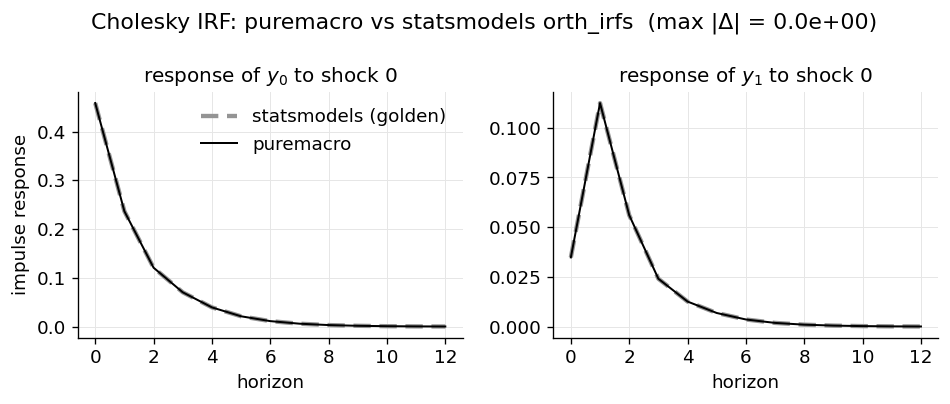

In [4]:
from puremacro.validation._fixtures import var_demo_data
from puremacro.validation._goldens import load_golden
from puremacro.var.identify import cholesky

d = var_demo_data()
pm = np.asarray(cholesky(d["Y"], p=d["p"], horizon=d["horizon"], n_boot=10, seed=0).irf_point)
ref = np.asarray(load_golden("var:cholesky_irf_vs_statsmodels")["irf"])
hz = np.arange(pm.shape[0])
max_diff = float(np.abs(pm - ref).max())

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.4))
for resp, ax in zip((0, 1), axes):
    ax.plot(hz, ref[:, resp, 0], color="0.58", lw=2.6, ls=(0, (4, 2)),
            label="statsmodels (golden)")
    ax.plot(hz, pm[:, resp, 0], color="0.0", lw=1.2, label="puremacro")
    ax.set_title(f"response of $y_{resp}$ to shock 0")
    ax.set_xlabel("horizon")
axes[0].set_ylabel("impulse response")
axes[0].legend(loc="best")
fig.suptitle(f"Cholesky IRF: puremacro vs statsmodels orth_irfs  (max |Δ| = {max_diff:.1e})")
fig.tight_layout()
plt.show()

## 3. `vfi` — política de crecimiento estocástico frente a la forma cerrada de Brock–Mirman
Un caso `analytical`: con utilidad logarítmica y depreciación total la política
óptima de capital tiene forma cerrada, $k' = \alpha\beta\,e^{z}k^{\alpha}$. La
política por iteración de la función de valor en malla cae sobre ella (en el
interior de la malla).

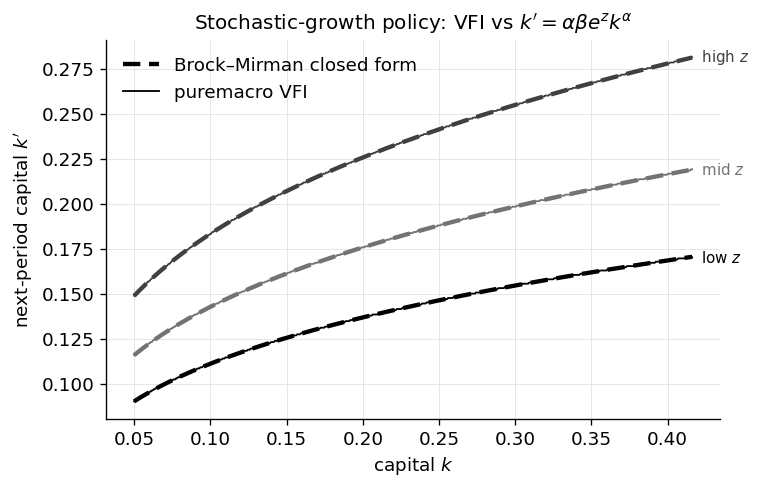

In [5]:
from puremacro.vfi.discretize import rouwenhorst
from puremacro.vfi.problem import VFIProblem

alpha, beta = 0.30, 0.95
z_log, P = rouwenhorst(5, 0.6, 0.10)
z_lev = np.exp(z_log)
k_ss = (alpha * beta) ** (1.0 / (1.0 - alpha))
k_grid = np.linspace(0.3 * k_ss, 2.5 * k_ss, 600)

def _return_fn(kp, k, z, xp=np):
    c = xp.exp(z) * k**alpha - kp                 # full depreciation: c = y - k'
    return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)

sol = VFIProblem(
    a_grid=k_grid, z_grid=z_log, P_z=P, return_fn=_return_fn, beta=beta,
    options=dict(tol=1e-10, n_howard=50, max_iter=20000),
).solve("numpy")
k_pol = k_grid[sol.policy_aprime]                 # (n_k, n_z)
k_closed = alpha * beta * z_lev[None, :] * k_grid[:, None] ** alpha

fig, ax = plt.subplots(figsize=(6.6, 4.1))
cols = _nbstyle.palette(3)
for col, zi, lab in zip(cols, (0, 2, 4), ("low $z$", "mid $z$", "high $z$")):
    ax.plot(k_grid, k_closed[:, zi], color=col, lw=2.6, ls=(0, (4, 2)))
    ax.plot(k_grid, k_pol[:, zi], color=col, lw=1.1)
    ax.text(k_grid[-1], k_pol[-1, zi], f"  {lab}", color=col, va="center", fontsize=9)
ax.plot([], [], color="0.0", lw=2.6, ls=(0, (4, 2)), label="Brock–Mirman closed form")
ax.plot([], [], color="0.0", lw=1.1, label="puremacro VFI")
ax.set_xlabel("capital $k$")
ax.set_ylabel("next-period capital $k'$")
ax.set_title(r"Stochastic-growth policy: VFI vs $k'=\alpha\beta e^{z}k^{\alpha}$")
ax.legend(loc="upper left")
plt.show()

## 4. `forecast` — CRPS gaussiano frente a la forma cerrada
Un caso `analytical` sobre una malla de errores estandarizados: `crps_gaussian`
contra la forma cerrada de Gneiting–Raftery (2007)
$\sigma[z(2\Phi(z)-1)+2\phi(z)-1/\sqrt{\pi}]$.

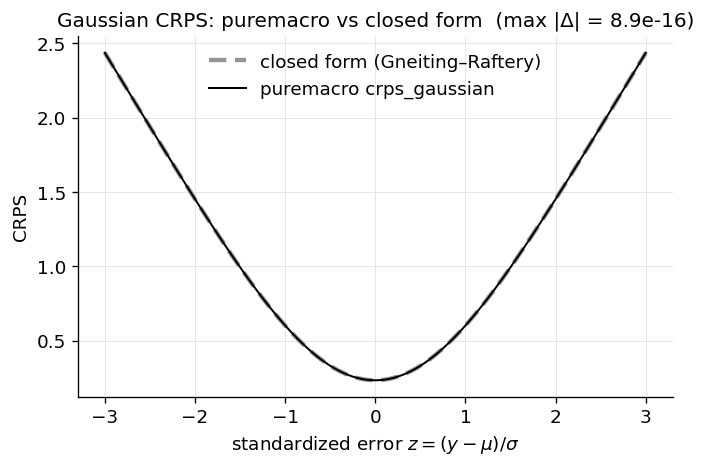

In [6]:
import math
from puremacro.forecast.density import crps_gaussian

z = np.linspace(-3.0, 3.0, 121)
pm_crps = np.array([crps_gaussian([zz], [0.0], [1.0])[0] for zz in z])
Phi = 0.5 * (1.0 + np.vectorize(math.erf)(z / np.sqrt(2.0)))
phi = np.exp(-0.5 * z**2) / np.sqrt(2.0 * np.pi)
cf = z * (2.0 * Phi - 1.0) + 2.0 * phi - 1.0 / np.sqrt(np.pi)   # sigma = 1

fig, ax = plt.subplots(figsize=(6.4, 3.9))
ax.plot(z, cf, color="0.58", lw=2.6, ls=(0, (4, 2)), label="closed form (Gneiting–Raftery)")
ax.plot(z, pm_crps, color="0.0", lw=1.2, label="puremacro crps_gaussian")
ax.set_xlabel(r"standardized error $z=(y-\mu)/\sigma$")
ax.set_ylabel("CRPS")
ax.set_title(f"Gaussian CRPS: puremacro vs closed form  (max |Δ| = {np.abs(pm_crps - cf).max():.1e})")
ax.legend(loc="upper center")
plt.show()

## 5. `spectral` — densidad espectral de Welch frente a `scipy.signal`
Un caso `scipy`: el estimador de Welch en `numpy.fft` puro de puremacro contra
`scipy.signal.welch` con el mismo estimador (ventana de Hann simétrica,
tendencia constante, escala de densidad, solapamiento igualado). puremacro
devuelve la densidad bilateral sobre la malla unilateral, así que aplicamos el
plegado unilateral estándar (×2 salvo en DC/Nyquist) para alinearlas. La serie
de ejemplo lleva una componente de ciclo de 16 períodos — el pico espectral que
ambos métodos recuperan.

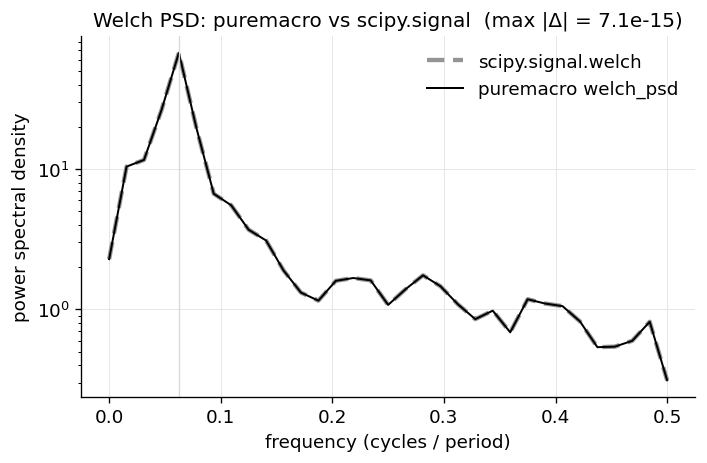

In [7]:
from scipy.signal import welch as scipy_welch
from puremacro.spectral import welch_psd
from puremacro.validation.cases_spectral import spectral_demo_data

s = spectral_demo_data()
f, Pxx = welch_psd(s["x"], fs=s["fs"], n_seg=s["n_seg"], overlap=s["overlap"])
fold = np.full(len(f), 2.0); fold[0] = 1.0; fold[-1] = 1.0     # one-sided fold (even segment)
Pxx = np.asarray(Pxx, dtype=float) * fold
f_sp, P_sp = scipy_welch(
    s["x"], fs=s["fs"], window=np.hanning(s["n_seg"]), nperseg=s["n_seg"],
    noverlap=s["noverlap"], detrend="constant", scaling="density",
)

fig, ax = plt.subplots(figsize=(6.6, 3.9))
ax.semilogy(f_sp, P_sp, color="0.58", lw=2.6, ls=(0, (4, 2)), label="scipy.signal.welch")
ax.semilogy(f, Pxx, color="0.0", lw=1.2, label="puremacro welch_psd")
ax.axvline(1.0 / 16.0, color="0.85", lw=0.8)
ax.set_xlabel("frequency (cycles / period)")
ax.set_ylabel("power spectral density")
ax.set_title(f"Welch PSD: puremacro vs scipy.signal  (max |Δ| = {np.abs(Pxx - P_sp).max():.1e})")
ax.legend(loc="upper right")
plt.show()

## Tu turno — audita un subsistema

El tablero `df` (calculado una sola vez en la sección 1) es toda la galería en
una tabla ordenada, así que puedes interrogarlo sin recalcular nada. Elige un
subsistema y confirma la afirmación que importa: tiene al menos un caso y
*todos* sus casos pasan. Cambia `my_subsystem` abajo por cualquier bloque —los
nombres disponibles se imprimen para ti (`var`, `lp`, `garch`, `inference`,
`state_space`, `spectral`, `forecast`, `vfi`, `dsge`, `dynpanel`, `narrative`).

In [8]:
print("available subsystems:", sorted(df["subsystem"].unique()))

my_subsystem = "spectral"          # ← change this to any subsystem above
sub = df[df["subsystem"] == my_subsystem]
n_sub, n_sub_pass = len(sub), int(sub["passed"].sum())
worst = float(sub["max_margin"].max())   # largest margin; <= 0 means all inside tolerance
print(f"{my_subsystem}: {n_sub_pass}/{n_sub} cases pass | worst margin = {worst:.1e}")

assert n_sub >= 1, f"no validation cases for subsystem {my_subsystem!r}"
assert sub["passed"].all(), f"a {my_subsystem} case failed"   # the subsystem certifies itself

available subsystems: ['dsge', 'dynpanel', 'forecast', 'garch', 'inference', 'lp', 'narrative', 'spectral', 'state_space', 'var', 'vfi']
spectral: 6/6 cases pass | worst margin = -1.0e-10


**Ejercicios.** (1) Cambia `my_subsystem` por `"narrative"` (el bloque más
grande, 7 casos) o `"var"` (el más pequeño, 3) y vuelve a ejecutar —el assert se
cumple para todos los subsistemas de la galería. (2) Filtra por *mecanismo* en su
lugar: `df[df["mechanism"] == "scipy"]` aísla las comprobaciones de scipy
recalculadas en vivo; confirma `.passed.all()` e inspecciona su `tol`. (3)
Encuentra el único caso con el mayor `max_margin`
(`df.loc[df["max_margin"].idxmax()]`) —el mayor margen reportado (los márgenes no son
directamente comparables entre niveles de tolerancia)— y lee su `citation` para ver
contra qué se contrasta.

**¿Qué tan exhaustivo es esto?** La galería abarca todos los subsistemas
principales de `puremacro` — `var` / `lp` / `garch` / `inference` /
`state_space` / `spectral` / `forecast` / `vfi` / `dsge` / `dynpanel` /
`narrative` — y crece con solo dejar un módulo `cases_<subsistema>.py` en
`puremacro/validation/`, que `run_all()` descubre automáticamente.
`docs/VALIDATION.md` enumera cada caso, su referencia y su cita, y documenta el
*alcance honesto*: donde no existe una referencia independiente sólida (p. ej.
las rutinas pesadas de estimación de DSGE, la vía narrativa con LLM), el caso se
omite con una razón declarada en lugar de sellarse con una comprobación
circular.

**Qué muestra esto sobre `puremacro.validation`:** la biblioteca incluye un
registro declarativo de casos de validación — `run_all()` los ejecuta todos y
`scorecard()` tabula puremacro frente a una referencia independiente en cada
caso. Los contrastes con paquetes (statsmodels / linearmodels / arch) se
congelan como valores golden y se reguardan contra los paquetes en vivo en CI
(`pytest -m reference`), de modo que `run_all()` se mantiene puro y ejecutable
en el navegador, mientras que las referencias de forma cerrada, scipy y de
identidad interna se recalculan aquí en vivo.
**Pruébalo:** `from puremacro.validation import scorecard; scorecard()` — o
añade un caso dejando un archivo `cases_<subsistema>.py` en el paquete.